# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coadd")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=7.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 93 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits']
LST hours from discovery (24): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Blue,None
1,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Full,None
2,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,00h,Green,None
3,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,00h,Red,None
4,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,01h,Blue,None
...,...,...,...,...
88,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Blue,None
89,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Full,None
90,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,22h,Green,None
91,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,22h,Red,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpe7q4y1k2.gaul.fits'
Detected ('00h', 'Blue'): 5401 sources -> sources_00h_Blue.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmphgb4_abx.gaul.fits'
Detected ('00h', 'Full'): 2772 sources -> sources_00h_Full.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


...

--> Wrote FITS file '/tmp/tmp335dy8l6.gaul.fits'
Detected ('22h', 'Green'): 2108 sources -> sources_22h_Green.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmpeudoka6u.gaul.fits'
Detected ('22h', 'Red'): 726 sources -> sources_22h_Red.parquet


stty: 'standard input': Inappropriate ioctl for device
stty: 'standard input': Inappropriate ioctl for device


--> Wrote FITS file '/tmp/tmp1mv3x6_q.gaul.fits'
Detected ('23h', 'Red'): 875 sources -> sources_23h_Red.parquet


## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). `BAND_FIELDS` / `ASSOC_BANDS` / `COLOR_BANDS` are
notebook constants.


In [6]:
BAND_FIELDS = (
    "Peak_flux",
    "Total_flux",
    "RA",
    "DEC",
    "Maj",
    "Min",
    "PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
)


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): 9258 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Full.parquet
LST merge (Blue): 17982 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Blue.parquet
LST merge (Green): 9423 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Green.parquet
LST merge (Red): 3506 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Red.parquet

Global metacatalog: 17766 sources from 238183 per-image detections
Wrote /fast/claw/metacatalog_coadd/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,PA_Red,DC_Maj_Red,DC_Min_Red,DC_PA_Red,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red
0,0,Full,"Full,Blue,Green,Red",-76.099320,1.431984,89.437455,207.320414,0.480392,0.236298,21.940526,...,24.372108,0.419068,0.135058,10.909855,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
1,1,Full,"Full,Blue,Green,Red",-107.063455,5.051490,67.977571,52.094278,0.426338,0.342450,47.210506,...,0.809278,0.000000,0.000000,0.000000,1,0.228941,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
2,2,Full,"Full,Blue,Green,Red",83.760318,21.917024,57.887246,69.875490,0.432547,0.290251,113.279746,...,52.561433,0.239636,0.221505,137.528499,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
3,17574,Green,"Green,Red",301.082148,41.799312,53.261763,41.559152,NaN,0.895200,178.616974,...,173.680438,0.000000,0.000000,0.000000,1,NaN,NaN,NaN,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
4,3,Full,"Full,Blue,Green,Red",76.157600,38.098088,51.565581,140.054336,0.467475,0.297723,17.649155,...,2.476406,0.223060,0.202549,156.759334,1,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
5,4,Full,"Full,Blue,Green,Red",-75.923276,1.164521,51.252849,120.221655,0.422775,0.360719,82.366479,...,24.372108,0.419068,0.135058,10.909855,1,0.228941,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
6,5,Full,"Full,Blue,Green,Red",-18.550745,39.677343,48.550860,118.395816,0.375291,0.315171,75.584078,...,14.346626,0.129242,0.067966,52.566524,1,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
7,6,Full,"Full,Blue,Green,Red",64.582771,38.024692,47.909108,33.012511,0.272176,0.153833,12.318436,...,77.733177,0.185378,0.113522,125.309017,1,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
8,7,Full,"Full,Blue,Green,Red",69.291024,29.691780,47.880186,145.210966,0.735125,0.355558,15.986597,...,8.490436,0.449952,0.182999,3.586764,1,0.225297,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...
9,8,Full,"Full,Blue,Green,Red",-56.411701,23.570604,46.824789,126.360603,0.425256,0.302307,57.970097,...,31.324625,0.241350,0.075968,46.317572,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 9258
  seen in multiple LST hours: 8295


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
7,69.291024,29.691780,47.880186,52,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",09h
15,-353.650154,64.130634,43.264404,46,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",19h
19,139.503393,-12.292442,39.305818,43,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
48,280.518640,79.774150,27.694165,42,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",03h
1,-107.063455,5.051490,67.977571,41,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",21h
2,83.760318,21.917024,57.887246,39,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
16,49.917364,41.506291,42.392939,37,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",08h
44,-324.243438,86.344249,28.524557,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",13h
3,76.157600,38.098088,51.565581,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",08h
123,319.607263,60.808438,20.953642,33,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",04h



Global rows by origin_band:
origin_band
Full     9258
Blue     8316
Green     147
Red        45
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 9158


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,-76.099320,1.431984,Full,89.437455,"14h,15h,16h,17h,18h,19h,20h,21h",2,1,1
1,1,-107.063455,5.051490,Full,67.977571,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",2,2,1
2,2,83.760318,21.917024,Full,57.887246,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",4,1,1
3,17574,301.082148,41.799312,Green,53.261763,04h,0,1,1
4,3,76.157600,38.098088,Full,51.565581,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
5,4,-75.923276,1.164521,Full,51.252849,"15h,16h,17h,18h,20h,21h,22h",3,1,1
6,5,-18.550745,39.677343,Full,48.550860,"00h,01h,02h,03h,04h,05h,06h,16h,17h,18h,19h,20...",1,1,1
7,6,64.582771,38.024692,Full,47.909108,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
8,7,69.291024,29.691780,Full,47.880186,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",3,1,1
9,8,-56.411701,23.570604,Full,46.824789,"00h,01h,02h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1


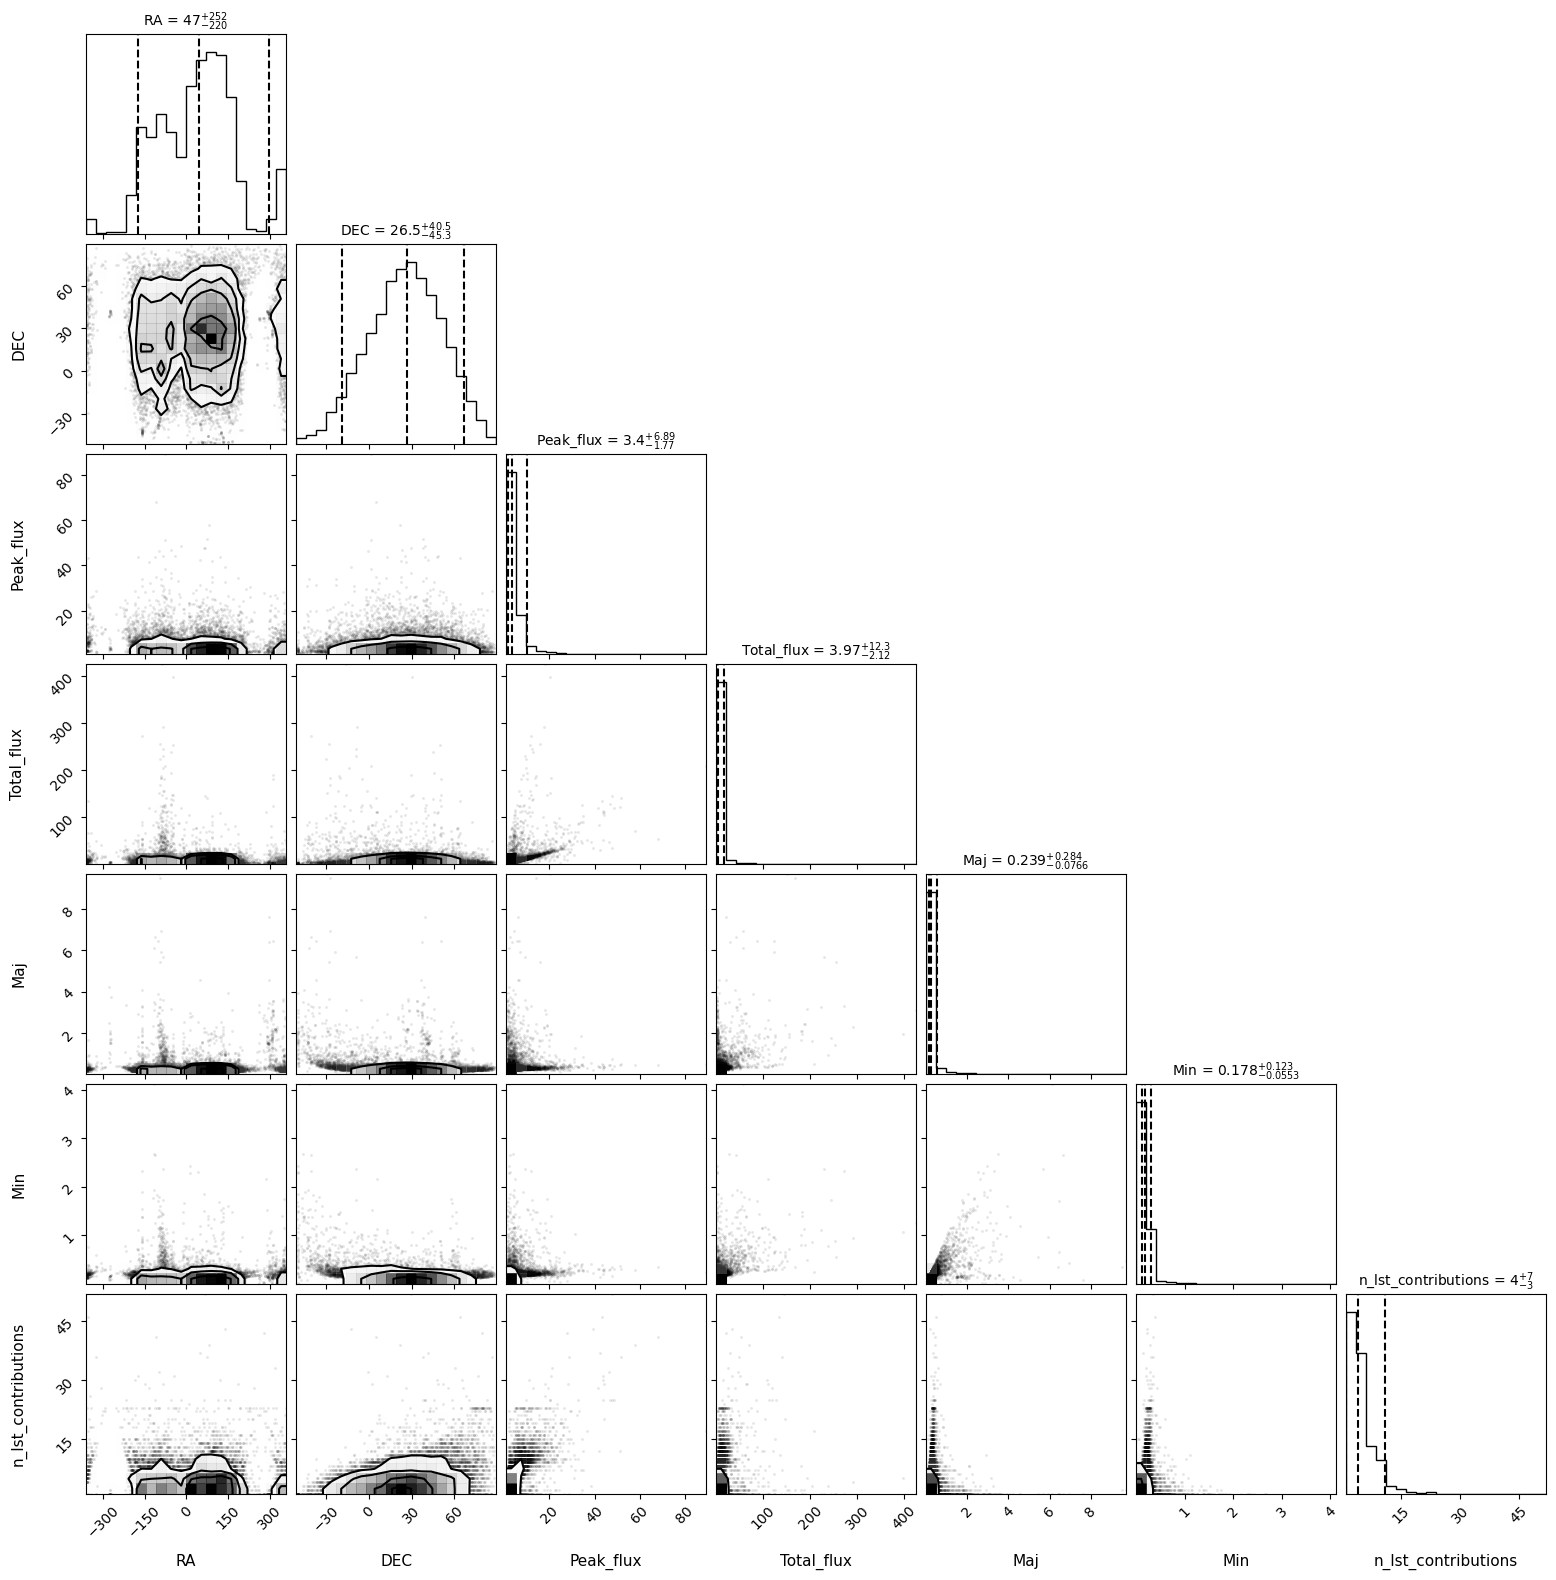

In [ ]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

plt.show()